# Surprise and surprise + DTW books on the combined book's terms

Reza's macro-surprise strategies and his surprise + DTW combinations (`Reza/`, notebooks
04–07), re-run on **the same data, years, costs and metrics as `backtest.py`**, so they sit
row for row next to the DTW event reaction book.

**Five books.** Two take their direction from the published consensus:

* **CPI · surprise model.** CPI only. The surprise `x` is the sign-adjusted, causal z-score
  of actual − Bloomberg median survey. A per-family slope of the 30-minute return on `x`
  is refit on earlier releases only; trade `sign(E[r])` when `|E[r]|` exceeds the
  round-trip cost.
* **All · naive.** The ~10 release families with the largest marginal impact (the same
  control idea as the combined book's screen, recomputed each year from history only),
  plus CPI. Position = `sign(x)`, one contract.

Three add a DTW signal (Reza's notebook 06 specification: the z-scored price path over
the 31 minutes up to entry, matched against earlier releases at the same clock slot,
3-year lookback, k = 15, Sakoe-Chiba band 5, recency half-life 2 years; `dtw_score` =
`dtw_dir / dtw_disp`, traded only outside the middle 40% of the previous three years'
scores):

* **All · DTW only.** The same releases as *All · naive*, direction = sign of `dtw_dir`.
* **All · surprise + DTW agree.** *All · naive*, kept only when DTW points the same way.
* **CPI · surprise + DTW agree.** *CPI · surprise model*, kept only when DTW agrees.

This DTW is one window per release (T+1); `backtest.py`'s DTW book is the five-window
ladder with its own settings, so the two DTW rows are related but not the same strategy.

**What is shared with `backtest.py`:** the cleaned bars (`futures_1min_clean_v3_*`), the
contract specs and cost levels in `config.py` (gross, a quarter tick and half a tick per
side), the session grid (18:00–17:00 ET, dated by the close), buy-and-hold with roll jumps
skipped, the metric definitions (daily bps, annualised over 252 sessions, summed not
compounded), and the equal-risk combined book. The test years are the same, 2021–2026.
One extra cost level is reported: 2 ticks round trip + $4.50 commission, the base case in
`Reza/`.

**What differs, by design:**

| | DTW book (`backtest.py`) | surprise book (this notebook) |
|---|---|---|
| direction | sign of `dtw_dir` | sign of the consensus surprise (and/or DTW, see above) |
| windows per release | five (T+1 … T+121) | one: entry at the close of the first post-release bar, exit 30 min after the print |
| fitting | gate and sizing tuned on 2013–2017 | walk-forward: screen, line signs and CPI slope refit each year on all earlier years |
| universe | families with impact t ≥ 2 | top-10 families by impact, plus CPI |

**The years.** 2013 is the first year of history (the same start as the combined book's
training years). Every year from 2018 is traded out of sample, so the notebook reports the
validation years (2018–2020) and the test years (2021–2026) separately. Nothing is tuned
here: the constants (`K_FAMILIES`, `MIN_TRAIN`, `THRESHOLD`) are the ones fixed in
`Reza/`. Honest caveat: those constants were chosen in `Reza/` while looking at
2019–2026, so, like the combined book, 2021–2026 is not a fully untouched test.

**YM (E-mini Dow).** When `futures_1min_clean_v3_YM.parquet` exists (`pull.py --pull YM`,
then `cleaning.py`), the five books are also run on YM, with the same code and constants,
and two more combined books are reported: ES + NQ + YM. YM is not in the DTW book, so it
has no DTW-book row in section 9. The three-market "combined" book stays ES + NQ + ZN.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
sys.path.insert(0, str(HERE))
sys.path.insert(0, str(HERE.parent / "Reza"))           # Reza's pipeline: Reza/src
from config import (ALL_ASSETS, ASSETS, BLOOMBERG, CLEAN_BARS_FMT, EXTRA_ASSETS, COST_TICKS_PER_SIDE, NY, OUT,
                    SESSION_SHIFT, TEST_YEARS_SPAN, TRAIN_YEARS_SPAN, VALID_YEARS_SPAN)
import src.surprise_universe as su
import src.state_conditioning as sc
import src.dtw_signal as ds

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

# The Bloomberg file is gitignored. Use the combined book's copy if it is there, else the one
# in Reza's project folder next to this repo.
BBG_CANDIDATES = [
    BLOOMBERG,
    HERE.parents[1] / ("BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-"
                       "to-Macroeconomic-Surprises") / "data/raw/Bloomberg Economic Releases.xlsx",
]
BBG_FILE = next((p for p in BBG_CANDIDATES if p.exists()), None)
assert BBG_FILE is not None, f"Bloomberg file not found in: {[str(p) for p in BBG_CANDIDATES]}"

BOOK_MARKETS = list(ASSETS)                                # ES, NQ, ZN: the DTW book's markets
EXTRA_MARKETS = [s for s in EXTRA_ASSETS if Path(CLEAN_BARS_FMT.format(symbol=s)).exists()]
symbols = BOOK_MARKETS + EXTRA_MARKETS                     # + YM once its cleaned file exists
SPEC = ALL_ASSETS                                          # tick and point value for every market
print("markets:", symbols)
HIST_START = f"{TRAIN_YEARS_SPAN[0]}-01-01"                 # first year of history
WF_YEARS = list(range(VALID_YEARS_SPAN[0], TEST_YEARS_SPAN[1] + 1))   # traded out of sample
PERIODS = {"validation": VALID_YEARS_SPAN, "test": TEST_YEARS_SPAN}
K_FAMILIES, MIN_TRAIN, THRESHOLD = 10, 24, 1.0             # fixed in Reza/, not tuned here
BOOKS = ["CPI · surprise model", "All · naive", "All · DTW only",
         "All · surprise + DTW agree", "CPI · surprise + DTW agree"]
CPI = "CPI"
# Reza's notebook 06 DTW specification
DTW = dict(lookback_years=3, max_pool=600, k=15, band=5, half_life_years=2.0)
GATE_MIDDLE, GATE_WINDOW = 0.40, 3

# cost levels: (ticks round trip, commission $ round trip); the first three are config.py's
COSTS = {name: (2 * t, 0.0) for name, t in COST_TICKS_PER_SIDE.items()}
COSTS["2 ticks + $4.50"] = (2.0, 4.5)
print(f"Bloomberg: {BBG_FILE}")
print(f"history from {HIST_START}; traded out of sample {WF_YEARS[0]}-{WF_YEARS[-1]}; "
      f"cost levels: {list(COSTS)}")

markets: ['ES', 'NQ', 'ZN', 'YM']
Bloomberg: /Users/reza/Desktop/mfe-term_3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises/data/raw/Bloomberg Economic Releases.xlsx
history from 2013-01-01; traded out of sample 2018-2026; cost levels: ['gross', 'quarter tick', 'half tick', '2 ticks + $4.50']


## 1. Releases, families and causal surprises

Release lines are grouped into families when their release times overlap by ≥ 80% (so
CPI MoM and Core CPI MoM are one trade). Each line's surprise is `actual − survey median`,
divided by the standard deviation of that line's **earlier** surprises (at least 24), and
capped at ±5.

In [2]:
rows = su.load_bloomberg(BBG_FILE)
fam = su.build_families(rows)
surp = su.standardise_surprises(rows)
surp = surp[surp["ticker"].isin(fam["ticker"])]
print(f"release rows: {len(rows):,} | families: {fam['family'].nunique()} | "
      f"surprises with a z-score: {surp['z'].notna().sum():,}")

release rows: 27,137 | families: 75 | surprises with a z-score: 17,328


## 2. One market, walk-forward

For every traded year `y`, using only releases before 1 January of `y`:
the **impact screen** ranks families by their mean |30-min reaction| over the same
statistic at the same clock slot on other families' releases, and keeps the top 10;
the **line signs** are the sign of each line's jump-on-surprise slope (a strong payrolls
print pushes ES up and ZN down, so signs are per market); the CPI slope is refit on
earlier CPI releases; and the **DTW gate** cut-offs come from the previous three years'
DTW scores. The DTW neighbour library uses every release from 2010 (the same burn-in as
the combined book), and a neighbour is used only if its 30-minute outcome was already known. Returns are from the close of the first post-release bar to the
close 30 minutes after the print, on the roll-adjusted log price.

In [3]:
def session_of(ts: pd.Series) -> pd.Series:
    """The trading session a timestamp belongs to (18:00-17:00 ET, dated by the close)."""
    return (ts.dt.tz_convert(NY) + SESSION_SHIFT).dt.normalize().dt.tz_localize(None)


def load_market(s: str):
    b = pd.read_parquet(CLEAN_BARS_FMT.format(symbol=s))
    b.index = pd.to_datetime(b.index, utc=True)
    b = b.sort_index()
    if "session_date" not in b.columns:
        b["session_date"] = session_of(b.index.to_series()).to_numpy()
    bars = sc.prepare_es_minute(b[["close", "contract"]].rename(columns={"contract": "instrument_id"}))
    adj, _ = sc.build_adjusted_log_price(bars)
    return b, adj


def surprise_market(s: str, adj: pd.DataFrame) -> dict:
    ts_all = rows.loc[rows["ts_utc"] >= pd.Timestamp(HIST_START, tz="UTC"), "ts_utc"].unique()
    px = su.price_measures(adj, ts_all)
    screens, admitted, signs, hist = {}, {}, {}, {}
    for y in WF_YEARS:
        screens[y] = su.impact_screen(rows, fam, px, HIST_START, f"{y}-01-01")
        admitted[y] = set(screens[y].head(K_FAMILIES)["family"]) if len(screens[y]) else set()
        signs[y] = su.line_signs(surp, px, HIST_START, f"{y}-01-01")
        hist[y] = su.history_panel(surp, fam, px, admitted[y] | {CPI}, signs[y], HIST_START,
                                   f"{y + 1}-01-01")
    fams = {y: pd.DataFrame({"family": sorted(admitted[y] | {CPI})}) for y in WF_YEARS}
    panel = su.family_signal_panel(surp, fam, px, fams, signs, WF_YEARS)
    panel["year"] = panel["ts_utc"].dt.tz_convert(NY).dt.year
    panel["admitted"] = [f in admitted[y] for f, y in zip(panel["family"], panel["year"])]

    # DTW on every release timestamp since 2010 (library), computed from 3 years before the
    # first traded year so the first gate has its history
    cal = (rows.groupby("ts_utc")["clock_et"].first().reset_index()
           .sort_values("ts_utc").reset_index(drop=True))
    px_all = su.price_measures(adj, cal["ts_utc"])
    cal = cal.merge(px_all[["ts_utc", "w1"]], on="ts_utc", how="left")
    paths = ds.zscore_rows(ds.extract_paths(adj, cal["ts_utc"]))
    qmask = (cal["ts_utc"] >= pd.Timestamp(f"{WF_YEARS[0] - GATE_WINDOW}-01-01", tz="UTC")).to_numpy()
    sig = ds.compute_dtw_signal(cal["ts_utc"], cal["clock_et"].to_numpy(), paths, cal["w1"].to_numpy(),
                                query_mask=qmask, progress_every=0, **DTW)
    gates = ds.gate_thresholds(sig, WF_YEARS, window_years=GATE_WINDOW, middle=GATE_MIDDLE)
    return dict(px=px, screens=screens, admitted=admitted, signs=signs, hist=hist, panel=panel,
                dtw=sig, gates=gates)


def with_dtw(t: pd.DataFrame, res: dict) -> pd.DataFrame:
    """Attach dtw_dir and the gated DTW position (0 inside the middle of the score range)."""
    t = t.merge(res["dtw"][["ts_utc", "dtw_dir", "dtw_score"]], left_on="timestamp_utc",
                right_on="ts_utc", how="left").drop(columns="ts_utc")
    y = t["timestamp_utc"].dt.tz_convert(NY).dt.year
    lo = y.map(lambda v: res["gates"][v][0])
    hi = y.map(lambda v: res["gates"][v][1])
    sc_ = t["dtw_score"]
    t["dtw_pos"] = np.where((sc_ < lo) | (sc_ > hi), np.sign(sc_), 0.0)
    t["dtw_pos"] = t["dtw_pos"].fillna(0.0)
    return t


def book_trades(res: dict, s: str, book: str, ticks_rt: float, commission_rt: float) -> pd.DataFrame:
    """One book at one cost level. The CPI model's trade/no-trade threshold is the cost, so
    it is rebuilt at every cost level; the naive and DTW positions do not depend on cost."""
    p = res["panel"].copy()
    p["cost_bps"] = su.cost_bps(p["pre_close"], ticks_rt, commission_rt,
                                SPEC[s]["tick"], SPEC[s]["point_value"])
    if book.startswith("CPI"):
        pos = su.build_positions(p[p["family"] == CPI], res["hist"], "surprise", "w1", MIN_TRAIN, THRESHOLD)
    else:
        pos = su.build_positions(p[p["admitted"]], res["hist"], "naive", "w1", MIN_TRAIN, THRESHOLD)
    t = with_dtw(su.to_trades(pos, "w1", book), res)
    if book == "All · DTW only":
        t["position"] = t["dtw_pos"]
    elif book.endswith("DTW agree"):
        t["position"] = np.where(np.sign(t["dtw_dir"]) == np.sign(t["position"]), t["position"], 0.0)
    t = ds.recost(t, book)
    t = t[(t["position"] != 0) & t["eligible"]].copy()
    t["session"] = session_of(t["timestamp_utc"])
    t["year"] = t["timestamp_utc"].dt.tz_convert(NY).dt.year
    return t


bars, results, trades = {}, {}, {}
for s in symbols:
    bars[s], adj = load_market(s)
    results[s] = surprise_market(s, adj)
    for book in BOOKS:
        for cname, (tk, cm) in COSTS.items():
            trades[(s, book, cname)] = book_trades(results[s], s, book, tk, cm)
    n = {b: len(trades[(s, b, "quarter tick")]) for b in BOOKS}
    print(f"{s}: {len(bars[s]):,} bars | release timestamps with a 30-min window: "
          f"{results[s]['px']['w1'].notna().sum():,} | trades {WF_YEARS[0]}-{WF_YEARS[-1]} "
          f"at a quarter tick: {n}")

ES: 5,392,615 bars | release timestamps with a 30-min window: 7,743 | trades 2018-2026 at a quarter tick: {'CPI · surprise model': 94, 'All · naive': 764, 'All · DTW only': 524, 'All · surprise + DTW agree': 397, 'CPI · surprise + DTW agree': 67}


NQ: 5,255,764 bars | release timestamps with a 30-min window: 7,574 | trades 2018-2026 at a quarter tick: {'CPI · surprise model': 98, 'All · naive': 761, 'All · DTW only': 500, 'All · surprise + DTW agree': 405, 'CPI · surprise + DTW agree': 64}


ZN: 5,392,031 bars | release timestamps with a 30-min window: 7,713 | trades 2018-2026 at a quarter tick: {'CPI · surprise model': 38, 'All · naive': 683, 'All · DTW only': 439, 'All · surprise + DTW agree': 369, 'CPI · surprise + DTW agree': 18}


YM: 5,195,343 bars | release timestamps with a 30-min window: 7,453 | trades 2018-2026 at a quarter tick: {'CPI · surprise model': 91, 'All · naive': 714, 'All · DTW only': 469, 'All · surprise + DTW agree': 378, 'CPI · surprise + DTW agree': 56}


**Findings:** 2018-2026 at a quarter tick: the naive book trades 764 releases on ES, 761 on
NQ and 683 on ZN (~85 a year). The CPI model trades 94 CPI prints on ES and 98 on NQ, but
only 38 on ZN, because a predicted ZN move rarely beats ZN's cost. Requiring DTW to agree
keeps about half of the naive trades (397 ES, 405 NQ, 369 ZN).

### Which families each market trades

Rank in the impact screen at the start of each year (top 10 are traded, plus CPI).

In [4]:
for s in symbols:
    r = results[s]
    ranks = pd.DataFrame({y: r["screens"][y].set_index("family")["rank"] for y in WF_YEARS})
    ranks = ranks[(ranks <= K_FAMILIES).any(axis=1)].sort_values(WF_YEARS[-1])
    print(f"\n{s}: families in the top {K_FAMILIES} in at least one year")
    print(ranks.astype("Int64").to_string())


ES: families in the top 10 in at least one year
                                       2018  2019  2020  2021  2022  2023  2024  2025  2026
family                                                                                     
CPI                                      10     4     5     7     3     1     1     1     1
Employment Report (NFP)                   1     1     1     1     1     3     2     2     2
Fed Interest on Reserve Balances Rate  <NA>  <NA>  <NA>  <NA>  <NA>     2     3     3     3
FOMC Rate Decision                        2     2     2     2     2     4     4     4     4
ISM Manufacturing                         3     5     4     6     8     5     6     5     5
U. of Michigan Sentiment                 34    25    27    17    13     6     5     6     6
ISM Services                              6     6     7     5     5     7     7     7     7
ISM Services Prices Paid               <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>     8
JOLTS                          

**Findings:** In the equity markets, NFP and CPI rank at the top every year (CPI #1 from
2023), followed by the FOMC decision, ISM Manufacturing and Services, and Retail Sales. The
FOMC decision is admitted here, unlike in the combined book's screen. From 2023 the Fed's
interest-on-reserves line enters too; it prints at the same minute as the FOMC decision, and
positions at one minute are averaged, so that minute is not traded twice. ZN's list is
shorter and steadier: NFP, FOMC, ISM Manufacturing, CPI and ISM Services.

## 3. Metrics — the same definitions as `backtest.py`

Daily bps of one contract's notional on the session grid, zero on days with no trade;
return, vol and Sharpe annualised over 252 sessions; beta against the asset's own
buy-and-hold. `metrics` and `buy_and_hold` are copied from `backtest.py` unchanged
(importing it would run the whole DTW backtest).

In [5]:
def buy_and_hold(s: str) -> pd.Series:
    """Daily bps from holding one contract, skipping the jump at each roll."""
    b = bars[s]
    r = np.log(b.close).diff() * 1e4
    r[b.contract.ne(b.contract.shift())] = 0.0
    return r.fillna(0.0).groupby(pd.DatetimeIndex(b.session_date)).sum()


def in_years(days: pd.DatetimeIndex, span: tuple[int, int]) -> pd.DatetimeIndex:
    return days[(days.year >= span[0]) & (days.year <= span[1])]


def metrics(daily: pd.Series, bench: pd.Series, t: pd.DataFrame | None = None,
            col: str | None = None) -> dict:
    ann = daily.mean() * 252 / 100
    vol = daily.std(ddof=1) * np.sqrt(252) / 100
    eq = daily.cumsum()
    out = {"total %": daily.sum() / 100, "ann return %": ann, "ann vol %": vol,
           "sharpe": ann / vol if vol else np.nan,
           "max DD %": float((eq - eq.cummax()).min()) / 100,
           "beta": float(np.cov(daily, bench)[0, 1] / bench.var()) if bench.var() else np.nan}
    if t is None:                                   # buy-and-hold
        out |= {"trades": np.nan, "win rate": float((daily > 0).mean()), "% long": 1.0,
                "% short": 0.0, "win rate long": float((daily > 0).mean()), "win rate short": np.nan}
    else:
        long, short = t[t.position > 0], t[t.position < 0]
        out |= {"trades": len(t), "win rate": float((t[col] > 0).mean()) if len(t) else np.nan,
                "% long": len(long) / len(t) if len(t) else np.nan,
                "% short": len(short) / len(t) if len(t) else np.nan,
                "win rate long": float((long[col] > 0).mean()) if len(long) else np.nan,
                "win rate short": float((short[col] > 0).mean()) if len(short) else np.nan}
    return out


def daily_pnl(t: pd.DataFrame, days: pd.DatetimeIndex, col: str = "net_bps") -> pd.Series:
    return t.groupby("session")[col].sum().reindex(days).fillna(0.0)


bnh = {s: buy_and_hold(s) for s in symbols}


def asset_table(s: str, span: tuple[int, int]) -> pd.DataFrame:
    days = in_years(bnh[s].index, span)
    bench = bnh[s].reindex(days)
    out = {}
    for book in BOOKS:
        for cname in COSTS:
            t = trades[(s, book, cname)]
            t = t[t["year"].between(*span)]
            out[f"{book}, {cname}"] = metrics(daily_pnl(t, days), bench, t, "net_bps")
    out["buy and hold"] = metrics(bench, bench)
    return pd.DataFrame(out).T


tables = {(s, per): asset_table(s, span) for s in symbols for per, span in PERIODS.items()}
COLS = ["trades", "total %", "sharpe", "max DD %", "win rate", "% long", "beta"]

## 4. ES — E-mini S&P 500 (test years 2021–2026)

In [6]:
print(tables[("ES", "test")][COLS].round(3).to_string())

                                             trades  total %  sharpe  max DD %  win rate  % long   beta
CPI · surprise model, gross                    65.0    3.532   0.515    -1.921     0.538   0.508  0.001
CPI · surprise model, quarter tick             62.0    3.457   0.510    -1.965     0.532   0.484  0.000
CPI · surprise model, half tick                57.0    2.900   0.437    -2.166     0.544   0.474  0.000
CPI · surprise model, 2 ticks + $4.50          50.0    3.578   0.612    -2.035     0.540   0.480  0.000
All · naive, gross                            527.0   17.232   1.179    -2.524     0.529   0.499 -0.002
All · naive, quarter tick                     527.0   15.863   1.086    -2.624     0.529   0.499 -0.002
All · naive, half tick                        527.0   14.494   0.993    -2.725     0.526   0.499 -0.002
All · naive, 2 ticks + $4.50                  527.0   10.770   0.739    -3.140     0.514   0.499 -0.002
All · DTW only, gross                         356.0   -2.184  -0

**Findings:** ES, 2021-2026. The naive surprise book makes 527 trades: Sharpe 1.18 gross,
1.09 at a quarter tick, 0.99 at half a tick and 0.74 at 2 ticks + $4.50, against 0.69 for
buy-and-hold. Max drawdown is −2.6% (buy-and-hold −31.1%) and beta about 0. Most of the gain
came in 2022 (about +12 of the +16%; see the figure below). The CPI model scores 0.51 on 62
trades. Its trade count and Sharpe move with the cost level, because the cost is also its
trade/no-trade threshold. DTW only loses money (−0.26). Requiring DTW to agree lowers the
naive book to 0.37. CPI + DTW agree scores 0.74, but on only 44 trades.

## 5. NQ — E-mini Nasdaq-100 (test years 2021–2026)

In [7]:
print(tables[("NQ", "test")][COLS].round(3).to_string())

                                             trades  total %  sharpe  max DD %  win rate  % long   beta
CPI · surprise model, gross                    65.0    4.137   0.462    -2.576     0.508   0.508 -0.001
CPI · surprise model, quarter tick             65.0    4.087   0.457    -2.605     0.508   0.508 -0.001
CPI · surprise model, half tick                64.0    4.474   0.504    -2.634     0.516   0.500 -0.002
CPI · surprise model, 2 ticks + $4.50          63.0    4.004   0.452    -2.743     0.508   0.492 -0.002
All · naive, gross                            528.0   14.566   0.767    -4.977     0.532   0.498 -0.002
All · naive, quarter tick                     528.0   14.158   0.746    -5.004     0.532   0.498 -0.002
All · naive, half tick                        528.0   13.750   0.724    -5.031     0.532   0.498 -0.002
All · naive, 2 ticks + $4.50                  528.0   12.198   0.643    -5.134     0.532   0.498 -0.002
All · DTW only, gross                         358.0   -4.748  -0

**Findings:** NQ, 2021-2026. The naive book makes 528 trades: Sharpe 0.77 gross, 0.75 at a
quarter tick and 0.64 at 2 ticks + $4.50, against 0.58 for buy-and-hold. Max drawdown is
−5.0% (buy-and-hold −48.3%). Costs matter little because one NQ tick is small next to its
moves. The CPI model scores 0.46, CPI + DTW agree 0.58, surprise + DTW agree 0.48, and DTW
only −0.28.

## 6. ZN — 10-year Treasury note (test years 2021–2026)

In [8]:
print(tables[("ZN", "test")][COLS].round(3).to_string())

                                             trades  total %  sharpe  max DD %  win rate  % long   beta
CPI · surprise model, gross                    65.0    0.120   0.033    -1.389     0.462   0.492  0.001
CPI · surprise model, quarter tick             25.0    0.432   0.171    -0.858     0.480   0.520  0.002
CPI · surprise model, half tick                10.0   -0.499  -0.305    -0.713     0.300   0.700  0.002
CPI · surprise model, 2 ticks + $4.50           1.0   -0.170  -0.431    -0.170     0.000   1.000 -0.000
All · naive, gross                            418.0    1.587   0.219    -2.162     0.493   0.471  0.000
All · naive, quarter tick                     418.0   -1.184  -0.164    -2.585     0.493   0.471 -0.000
All · naive, half tick                        418.0   -3.954  -0.545    -4.664     0.486   0.471 -0.000
All · naive, 2 ticks + $4.50                  418.0  -11.091  -1.507   -11.277     0.419   0.471 -0.001
All · DTW only, gross                         274.0    2.927   0

**Findings:** ZN, 2021-2026: nothing survives realistic costs. The naive book goes from
0.22 gross to −0.16 at a quarter tick and −1.51 at 2 ticks + $4.50. At our cost the CPI model
makes a single trade, because its cost threshold shuts it off. DTW only is +0.50 gross but
+0.19 at a quarter tick. This matches the combined book: one ZN tick is too large for ZN's
30-minute moves.

## 6b. YM — E-mini Dow (test years 2021–2026)

Only when YM's cleaned file exists. Same code and constants as ES, NQ and ZN.

In [9]:
if "YM" in symbols:
    print(tables[("YM", "test")][COLS].round(3).to_string())
else:
    print("YM not available: run `uv run python combined/pull.py --pull YM` and `cleaning.py` first.")

                                             trades  total %  sharpe  max DD %  win rate  % long   beta
CPI · surprise model, gross                    63.0    2.512   0.445    -2.218     0.492   0.524  0.002
CPI · surprise model, quarter tick             59.0    2.177   0.392    -2.233     0.475   0.508  0.002
CPI · surprise model, half tick                58.0    2.223   0.401    -2.247     0.483   0.517  0.002
CPI · surprise model, 2 ticks + $4.50          48.0    1.527   0.288    -1.965     0.458   0.500  0.002
All · naive, gross                            483.0   14.355   1.108    -1.939     0.518   0.495  0.001
All · naive, quarter tick                     483.0   13.704   1.058    -1.972     0.518   0.495  0.001
All · naive, half tick                        483.0   13.054   1.008    -2.004     0.513   0.495  0.001
All · naive, 2 ticks + $4.50                  483.0   10.581   0.819    -2.409     0.507   0.495  0.001
All · DTW only, gross                         317.0    4.946   0

**Findings:** YM, 2021-2026. The naive book makes 483 trades: Sharpe 1.11 gross, 1.06 at a
quarter tick, 1.01 at half a tick and 0.82 at 2 ticks + $4.50, against 0.67 for buy-and-hold,
with a −2.0% max drawdown (buy-and-hold −25.6%) and no beta: close to ES (1.09) and above NQ
(0.75). The CPI model scores 0.39. Unlike ES and NQ, **DTW does not lose on YM**: DTW only
scores 0.44 (0.40 in 2018-2020, so the same sign in both periods), and surprise + DTW agree
1.04 on 257 trades with a −1.6% drawdown, about the naive book's Sharpe with half the trades.
In validation (2018-2020) the naive book scores 1.27 at a quarter tick.

## 7. Validation years (2018–2020), all markets

Also out of sample (walk-forward), but outside the test window. A book that only works in
one of the two periods is fragile.

In [10]:
val = pd.concat({s: tables[(s, "validation")]["sharpe"] for s in symbols}, axis=1)
tst = pd.concat({s: tables[(s, "test")]["sharpe"] for s in symbols}, axis=1)
print("Sharpe, validation 2018-2020:")
print(val.round(2).to_string())
print("\nSharpe, test 2021-2026:")
print(tst.round(2).to_string())

Sharpe, validation 2018-2020:
                                               ES    NQ    ZN    YM
CPI · surprise model, gross                  1.11  0.99 -1.18  1.23
CPI · surprise model, quarter tick           1.27  0.96 -0.64  1.08
CPI · surprise model, half tick              1.17  0.95  0.34  1.34
CPI · surprise model, 2 ticks + $4.50        1.22  1.06   NaN  1.15
All · naive, gross                           1.20  0.91 -0.09  1.34
All · naive, quarter tick                    1.04  0.86 -0.91  1.27
All · naive, half tick                       0.88  0.82 -1.72  1.20
All · naive, 2 ticks + $4.50                 0.45  0.63 -3.64  0.94
All · DTW only, gross                        0.70  0.82 -0.07  0.46
All · DTW only, quarter tick                 0.57  0.78 -0.71  0.40
All · DTW only, half tick                    0.44  0.74 -1.33  0.34
All · DTW only, 2 ticks + $4.50              0.08  0.59 -2.79  0.13
All · surprise + DTW agree, gross            1.58  1.25 -0.43  0.67
All · surprise + D

**Findings:** The surprise books hold up in both periods on the equity markets. At a quarter
tick the naive book scores ES 1.04 in validation and 1.09 in test, NQ 0.86 and 0.75. The CPI
model is stronger in validation (1.27, 0.96) than in test (0.51, 0.46). **DTW flips
between the periods:** DTW only scores +0.57 and +0.78 in 2018-2020 but −0.26 and −0.28 in
2021-2026, the same break as the combined book's `dtw_dir` sign flip. So surprise + DTW agree
beats the naive book in validation (1.46, 1.21) and loses to it in test (0.37, 0.48). The
DTW filter does not carry over. ZN is negative in both periods at any real cost.

## 8. Combined books vs an equal-risk buy-and-hold

The same construction as `backtest.py`: each asset's strategy P&L weighted by
1 / its median absolute 30-minute move on its traded families, each asset's buy-and-hold
by 1 / its daily vol, weights normalised to sum to one. Here the weights come from
**2013–2017 only**, before both the validation and the test years, so neither period sees
its own volatility. Two books: all three markets (as in `backtest.py`) and ES + NQ, since
a single ZN tick is large next to ZN's 30-minute moves in both workstreams.

In [11]:
FIT = TRAIN_YEARS_SPAN
first = WF_YEARS[0]
h = {s: results[s]["hist"][first] for s in symbols}
w_strat = pd.Series({s: 1 / h[s].loc[h[s]["ts_utc"] < pd.Timestamp(f"{first}-01-01", tz="UTC"), "w1"]
                     .abs().median() for s in symbols})
w_bnh = pd.Series({s: 1 / bnh[s].reindex(in_years(bnh[s].index, FIT)).std() for s in symbols})
print(pd.DataFrame({"strategy weight": w_strat / w_strat.sum(),
                    "buy-and-hold weight": w_bnh / w_bnh.sum()}).round(3).to_string())


def combined_table(members: list[str], span: tuple[int, int]) -> pd.DataFrame:
    ws, wb = w_strat[members] / w_strat[members].sum(), w_bnh[members] / w_bnh[members].sum()
    days = in_years(bnh[members[0]].index, span)
    for s in members[1:]:
        days = days.union(in_years(bnh[s].index, span))
    bench = sum(wb[s] * bnh[s].reindex(days).fillna(0.0) for s in members)
    out = {}
    for book in BOOKS:
        for cname in COSTS:
            ts = {s: trades[(s, book, cname)] for s in members}
            ts = {s: t[t["year"].between(*span)] for s, t in ts.items()}
            daily = sum(ws[s] * daily_pnl(ts[s], days) for s in members)
            out[f"{book}, {cname}"] = metrics(daily, bench, pd.concat(ts.values()), "net_bps")
    out["equal-risk buy and hold"] = metrics(bench, bench)
    return pd.DataFrame(out).T


COMBOS = {"combined": BOOK_MARKETS, "ES+NQ": ["ES", "NQ"]}
if "YM" in symbols:
    COMBOS["ES+NQ+YM"] = ["ES", "NQ", "YM"]
for name, members in COMBOS.items():
    for per, span in PERIODS.items():
        tables[(name, per)] = combined_table(members, span)
print("\nAll three markets, test 2021-2026:")
print(tables[("combined", "test")][COLS].round(3).to_string())
print("\nES + NQ, test 2021-2026:")
print(tables[("ES+NQ", "test")][COLS].round(3).to_string())
if "ES+NQ+YM" in COMBOS:
    print("\nES + NQ + YM, test 2021-2026:")
    print(tables[("ES+NQ+YM", "test")][COLS].round(3).to_string())

    strategy weight  buy-and-hold weight
ES            0.246                0.184
NQ            0.181                0.154
ZN            0.333                0.465
YM            0.240                0.197



All three markets, test 2021-2026:
                                             trades  total %  sharpe  max DD %  win rate  % long   beta
CPI · surprise model, gross                   195.0    2.181   0.391    -1.721     0.503   0.503  0.001
CPI · surprise model, quarter tick            152.0    2.281   0.475    -1.417     0.513   0.500  0.002
CPI · surprise model, half tick               131.0    1.785   0.398    -1.546     0.511   0.504  0.001
CPI · surprise model, 2 ticks + $4.50         114.0    2.037   0.532    -1.156     0.518   0.491 -0.000
All · naive, gross                           1473.0    9.744   1.028    -1.929     0.520   0.491  0.000
All · naive, quarter tick                    1473.0    7.989   0.844    -2.093     0.520   0.491 -0.000
All · naive, half tick                       1473.0    6.234   0.659    -2.257     0.517   0.491 -0.000
All · naive, 2 ticks + $4.50                 1473.0    1.531   0.162    -3.795     0.494   0.491 -0.000
All · DTW only, gross       

**Findings (ES + NQ + YM):** adding YM to ES + NQ raises the naive book from 1.00 to **1.08** at a
quarter tick and from 0.76 to **0.82** at 2 ticks + $4.50, on 1,538 trades, and lowers the max
drawdown from −2.9% to −2.3%; the equal-risk buy-and-hold scores 0.67. The three-market book
(ES + NQ + ZN) is unchanged.

**Findings:** Equal risk gives ZN 44% of the strategy weight, so ZN decides the
three-market book at higher costs. The naive book scores 0.84 at a quarter tick but 0.16 at
2 ticks + $4.50. **ES + NQ is the robust book:** the naive book scores 1.00 at a quarter tick
and 0.76 at 2 ticks + $4.50 on 1,055 trades, with a −2.9% max drawdown against −38.8% for the
equal-risk buy-and-hold (Sharpe 0.64). The three-market buy-and-hold Sharpe is 0.29 here
against 0.18 in `backtest.py`, because these weights come from 2013-2017 rather than
2013-2020.

## 9. Side by side with the DTW book (test years 2021–2026)

The DTW rows come from `output/backtest_summary.csv` when `backtest.py` has been run on
this machine; otherwise from the numbers in the combined README (commit ac384c3,
2026-09-30). Sharpe, same years, same cost levels. The DTW book's multi-asset books use
inverse-vol weights with a cost gate; its "equities" book is compared with ES + NQ here.
The surprise combined books use fixed equal-risk weights from 2013–2017, so the combined
rows compare books, not identical weightings. YM and ES + NQ + YM have no DTW-book row.

In [12]:
DTW_REPORTED = {   # combined README (ac384c3): (trades, gross, quarter tick, half tick, buy and hold)
    "ES": (1202, 0.78, 0.64, 0.49, 0.69), "NQ": (1141, 0.14, 0.11, 0.08, 0.58),
    "ZN": (1945, 0.34, -0.97, -2.24, -0.69), "equities": (2343, 0.66, 0.54, 0.42, 0.65),
    "combined": (2476, 0.76, 0.40, 0.41, 0.24),
}
DTW_NAME = {"ES": "ES", "NQ": "NQ", "ZN": "ZN", "ES+NQ": "equities", "combined": "combined"}
CMP_BOOKS = ["ES", "NQ", "ZN", "ES+NQ", "combined"] + [b for b in ["YM", "ES+NQ+YM"]
                                                         if b in symbols or b in COMBOS]
summary_path = OUT / "backtest_summary.csv"
dtw = {}
if summary_path.exists():
    bs = pd.read_csv(summary_path, index_col=[0, 1])
    for book in [b for b in set(DTW_NAME.values()) if b in bs.index.get_level_values(0)]:
        b = bs.loc[book]
        by_cost = [next(r for r in b.index if r.endswith(f", {c}")) for c in COST_TICKS_PER_SIDE]
        dtw[book] = (b.loc[by_cost[1], "trades"], *[b.loc[r, "sharpe"] for r in by_cost],
                     b.loc[[r for r in b.index if "buy and hold" in r][0], "sharpe"])
    source = "output/backtest_summary.csv"
else:
    dtw, source = DTW_REPORTED, "combined README (commit ac384c3, 2026-09-30)"

cmp_rows = []
for book in CMP_BOOKS:
    if DTW_NAME.get(book) in dtw:
        n, g, q, hf, bh = dtw[DTW_NAME[book]]
        cmp_rows.append({"market": book, "book": "DTW (backtest.py)", "trades": n, "gross": g,
                         "quarter tick": q, "half tick": hf, "2 ticks + $4.50": np.nan, "buy and hold": bh})
    tb = tables[(book, "test")]
    for bk in BOOKS:
        cmp_rows.append({"market": book, "book": bk,
                         "trades": tb.loc[f"{bk}, quarter tick", "trades"],
                         **{c: tb.loc[f"{bk}, {c}", "sharpe"] for c in COSTS},
                         "buy and hold": tb.loc[[r for r in tb.index if "buy and hold" in r][0], "sharpe"]})
comparison = pd.DataFrame(cmp_rows).set_index(["market", "book"])
print(f"DTW rows from: {source}\n")
print(comparison.round(2).to_string())

DTW rows from: backtest.py findings (commit 75f76b9)

                                     trades  gross  quarter tick  half tick  2 ticks + $4.50  buy and hold
market   book                                                                                             
ES       DTW (backtest.py)           1202.0   0.78          0.64       0.49              NaN          0.69
         CPI · surprise model          62.0   0.51          0.51       0.44             0.61          0.69
         All · naive                  527.0   1.18          1.09       0.99             0.74          0.69
         All · DTW only               356.0  -0.18         -0.26      -0.33            -0.54          0.69
         All · surprise + DTW agree   271.0   0.44          0.37       0.30             0.12          0.69
         CPI · surprise + DTW agree    44.0   0.80          0.74       0.62             0.88          0.69
NQ       DTW (backtest.py)           1141.0   0.14          0.11       0.08              N

**Findings:** Same years, same costs, same metrics, 2021-2026 at a quarter tick, against the
DTW book's current version (ac384c3). The naive surprise book beats the DTW book on ES (1.09
vs 0.64), NQ (0.75 vs 0.11), ES + NQ (1.00 vs 0.54, the DTW "equities" book) and the
three-market book (0.84 vs 0.40, with different weightings), with about a third of the trades.
Neither book survives costs on ZN. The two books lose in different years: the DTW equities book's
only losing year is 2022, which is the surprise book's best. Single-window DTW adds nothing on
top of the surprise: on its own it loses in the equity markets, and as a filter it lowers the
naive book (ES 0.37, NQ 0.48). On YM, which the DTW book does not trade, the naive book
scores 1.06 and ES + NQ + YM 1.08; single-window DTW is positive there (0.44) and DTW agreement
keeps the naive book's level (1.04) with half the trades.
Caveats: much of the surprise book's gain is from 2022, and its constants were fixed in
`Reza/` while looking at 2019-2026, so 2021-2026 is not an untouched test for either book.

## 10. Cumulative P&L, test years, a quarter tick per side

ES+NQ (and ES+NQ+YM when YM is available) are equal-risk combinations of the equity markets.

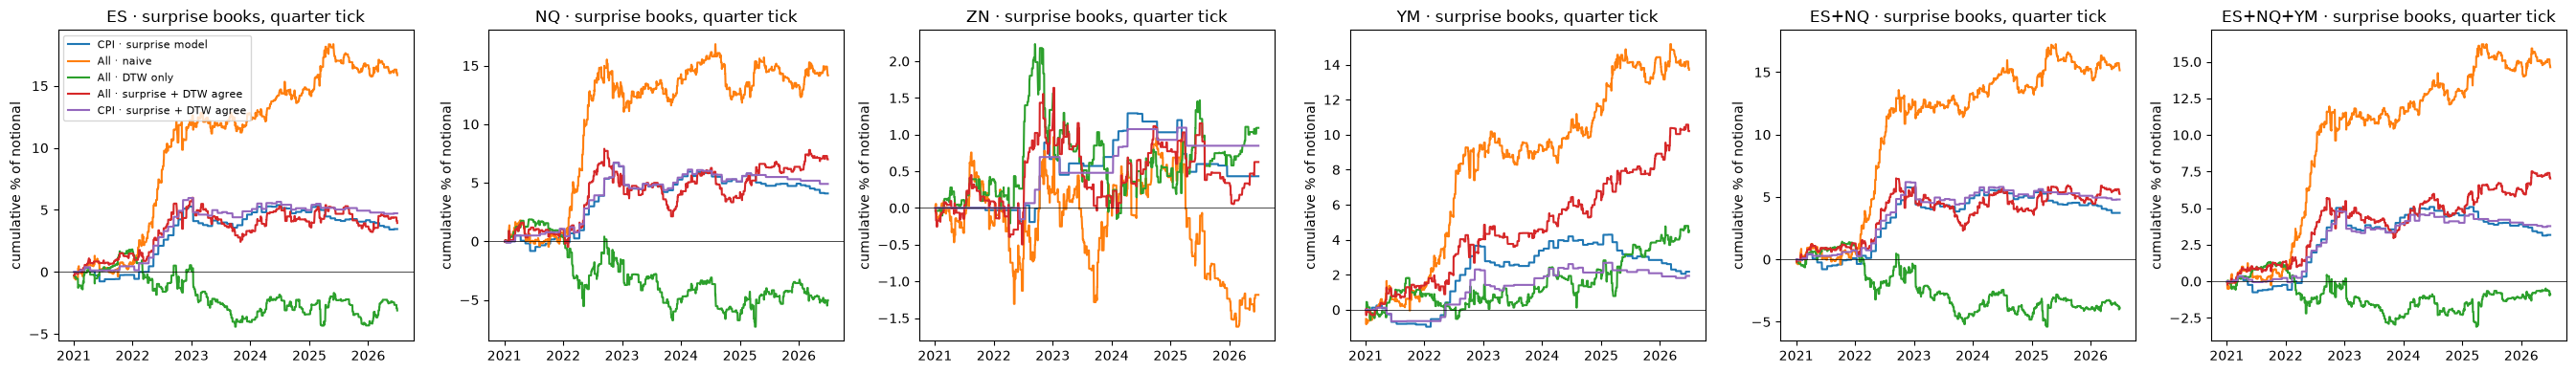

In [13]:
PANELS = symbols + [c for c in ["ES+NQ", "ES+NQ+YM"] if c in COMBOS]
fig, axes = plt.subplots(1, len(PANELS), figsize=(4.5 * len(PANELS), 4), sharex=True)
for ax, s in zip(axes, PANELS):
    members = COMBOS[s] if s in ("ES+NQ", "ES+NQ+YM") else [s]
    ws = w_strat[members] / w_strat[members].sum()
    days = in_years(bnh[members[0]].index, TEST_YEARS_SPAN)
    for book in BOOKS:
        d = sum(ws[m] * daily_pnl(trades[(m, book, "quarter tick")], days) for m in members)
        ax.plot(d.index, d.cumsum() / 100, label=book)
    ax.axhline(0, c="k", lw=0.5)
    ax.set_title(f"{s} · surprise books, quarter tick")
    ax.set_ylabel("cumulative % of notional")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / "surprise_dtw_book_cumulative.png", dpi=150)
plt.show()

In [14]:
pd.concat({f"{k[0]} · {k[1]}": v for k, v in tables.items()}, names=["book", "row"]).to_csv(
    OUT / "surprise_dtw_book_summary.csv")
comparison.to_csv(OUT / "surprise_vs_dtw_test.csv")
print("wrote surprise_dtw_book_summary.csv, surprise_vs_dtw_test.csv, surprise_dtw_book_cumulative.png")

wrote surprise_dtw_book_summary.csv, surprise_vs_dtw_test.csv, surprise_dtw_book_cumulative.png
